In [1]:
import os

def collect_parent_ids(subset):
    base_dataset = getattr(subset, "dataset", subset)
    indices = getattr(subset, "indices", range(len(subset)))

    parent_ids = set()
    for idx in indices:
        filepath = base_dataset.samples[idx][0]
        filename = os.path.basename(filepath)
        
        # 1. Clean the prefixes
        if filename.startswith("transfer_"):
            filename = filename[len("transfer_"):]
        elif filename.startswith("redigital_"):
            filename = filename[len("redigital_"):]
            
        # 2. Strip the extension (.png or .jpg)
        parent_id, _ = os.path.splitext(filename)
        parent_ids.add(parent_id)
        
    return parent_ids

# Create the loaders if not already in memory
if 'train_loader' not in globals() or 'val_loader' not in globals():
    from src.data.dataloader import get_dataloaders
    train_loader, val_loader = get_dataloaders(data_dir="src/data/RRDataset_final", batch_size=64)

# Get subsets from loaders
train_subset = train_loader.dataset
val_subset = val_loader.dataset

print("Scanning Training Set (Extracting parent IDs)...")
train_parent_ids = collect_parent_ids(train_subset)

print("Scanning Validation Set (Extracting parent IDs)...")
val_parent_ids = collect_parent_ids(val_subset)

# Find the true leakage
leaked_parents = train_parent_ids.intersection(val_parent_ids)

print("\n--- TRUE LEAKAGE REPORT ---")
print(f"Unique parent images in Train: {len(train_parent_ids)}")
print(f"Unique parent images in Val:   {len(val_parent_ids)}")
print(f"TRUE LEAKED PARENT IMAGES:     {len(leaked_parents)}")

if len(leaked_parents) > 0:
    print(f"Percentage of Val subjects leaked: {(len(leaked_parents)/len(val_parent_ids))*100:.2f}%")
    print("\nExamples of leaked parent subjects:")
    for parent in list(leaked_parents)[:5]:
        print(f" - {parent}")
else:
    print("\nZero leakage! Your split is truly safe.")


Loaded 12 images.
Scanning Training Set (Extracting parent IDs)...
Scanning Validation Set (Extracting parent IDs)...

--- TRUE LEAKAGE REPORT ---
Unique parent images in Train: 9
Unique parent images in Val:   3
TRUE LEAKED PARENT IMAGES:     0

Zero leakage! Your split is truly safe.


In [2]:
from src.data.dataloader import get_dataloaders

train_loader, val_loader = get_dataloaders(data_dir="src/data/RRDataset_final", batch_size=64)

# Grab one batch
sample = next(iter(train_loader))

print(f"Images shape: {sample[0].shape}")       # Should be [32, 3, 224, 224]
print(f"Real/Fake labels: {sample[1]}")      # Should be a mix of 0s and 1s
print(f"Transform labels: {sample[2]}")   # Should be a mix of 0s, 1s, and 2s

Loaded 12 images.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Images shape: torch.Size([9, 3, 224, 224])
Real/Fake labels: tensor([1, 1, 0, 1, 1, 0, 0, 1, 0])
Transform labels: tensor([0, 2, 2, 0, 1, 1, 1, 1, 0])


In [3]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# Import your custom modules directly from the src directory
from src.train.loss import MultiTaskLoss
from src.train.loops import MultiTaskModel, train_epoch
from src.train.ablation import run_ablation_study

# Set device to GPU if available
device = torch.device(
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
    )
print(f"Using device: {device}")

Using device: cpu


In [4]:
print("Starting Ablation Study Runs...")
# This will execute the run_ablation_study() function from your module
run_ablation_study(train_loader, val_loader)

Starting Ablation Study Runs...

--- Running iteration with Alpha=0.5, Beta=0.5 ---
Epoch [1/10] - Train Loss: 0.9323, Val Loss: 0.9223
Saving improved model to models/model_05_05.pth...
Epoch [2/10] - Train Loss: 0.8195, Val Loss: 0.9298
No improvement. Patience: 1/3
Epoch [3/10] - Train Loss: 0.7660, Val Loss: 0.9345
No improvement. Patience: 2/3
Epoch [4/10] - Train Loss: 0.6975, Val Loss: 0.9419
No improvement. Patience: 3/3
Early stopping triggered! Moving to next weight combination.

Ablation Study Complete. Summary:
Weights (alpha=0.5, beta=0.5)
  -> Final Train Loss: 0.6975
  -> Final Val Loss:   0.9419
  -> Final Val Acc (RF): 0.6667
  -> Final Val Acc (TF): 0.0000


Running evaluation on validation set...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



--- Final Results ---
Overall Real/Fake Accuracy:   66.67%
Overall Transform Accuracy:   33.33%

--- Advanced Metrics (Real/Fake Task) ---
Precision: 0.5000
Recall:    1.0000
F1 Score:  0.6667
ROC AUC:   0.7500


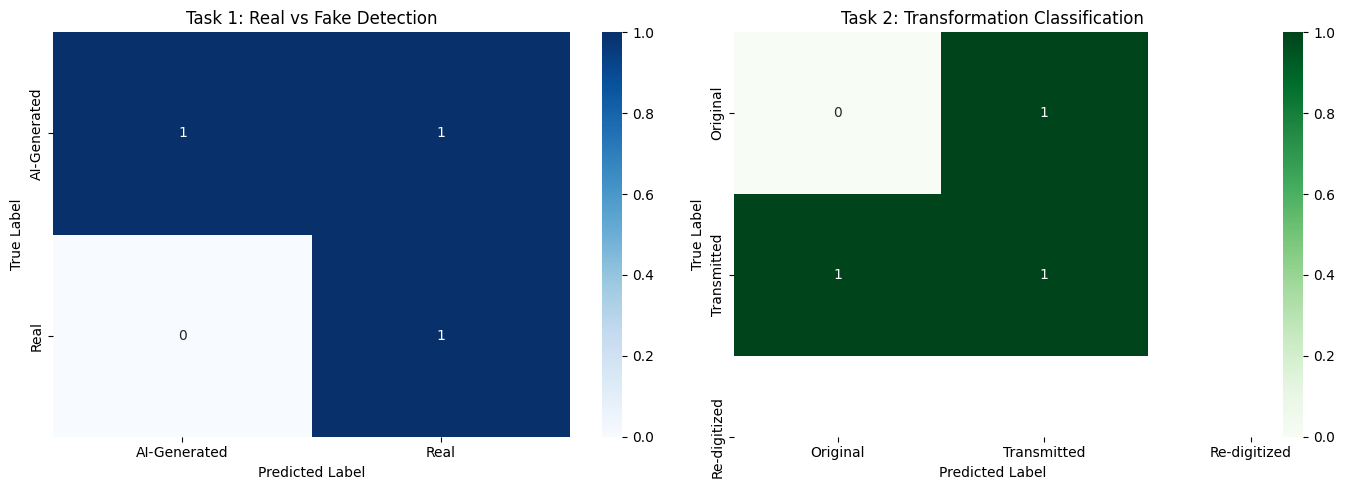

Saved: confusion_matrices.png


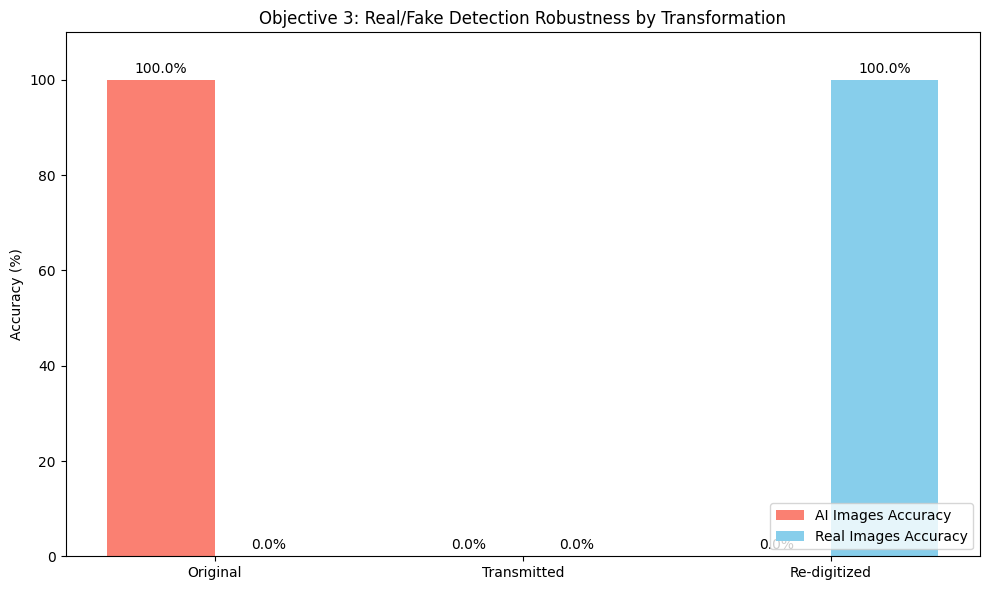

Saved: accuracy_breakdown.png
Grading 1.0_0.0...


RuntimeError: Error(s) in loading state_dict for MultiTaskModel:
	Missing key(s) in state_dict: "spatial_backbone.conv1.weight", "spatial_backbone.bn1.weight", "spatial_backbone.bn1.bias", "spatial_backbone.bn1.running_mean", "spatial_backbone.bn1.running_var", "spatial_backbone.layer1.0.conv1.weight", "spatial_backbone.layer1.0.bn1.weight", "spatial_backbone.layer1.0.bn1.bias", "spatial_backbone.layer1.0.bn1.running_mean", "spatial_backbone.layer1.0.bn1.running_var", "spatial_backbone.layer1.0.conv2.weight", "spatial_backbone.layer1.0.bn2.weight", "spatial_backbone.layer1.0.bn2.bias", "spatial_backbone.layer1.0.bn2.running_mean", "spatial_backbone.layer1.0.bn2.running_var", "spatial_backbone.layer1.0.conv3.weight", "spatial_backbone.layer1.0.bn3.weight", "spatial_backbone.layer1.0.bn3.bias", "spatial_backbone.layer1.0.bn3.running_mean", "spatial_backbone.layer1.0.bn3.running_var", "spatial_backbone.layer1.0.downsample.0.weight", "spatial_backbone.layer1.0.downsample.1.weight", "spatia

In [5]:
import torch
from src.train.loops import MultiTaskModel
from src.evaluation.visualizer import evaluate_model, plot_ablation_study

best_model = MultiTaskModel().to(device)

best_model.load_state_dict(torch.load("models/model_05_05.pth", map_location=device))

evaluate_model(best_model, val_loader, device)

# Plot the ablation study
model_files = {
    '1.0_0.0': 'models/model_10_00.pth',
    '0.0_1.0': 'models/model_00_10.pth',
    '0.5_0.5': 'models/model_05_05.pth',
    '0.8_0.2': 'models/model_08_02.pth',
    '0.2_0.8': 'models/model_02_08.pth'
}

real_ablation_results = {}

for weight_key, file_path in model_files.items():
    print(f"Grading {weight_key}...")
    
    # Load each saved model one by one
    temp_model = MultiTaskModel().to(device)
    temp_model.load_state_dict(torch.load(file_path, map_location=device))
    
    # Run the validation loop to get the real accuracies
    acc_rf, acc_trans = evaluate_model(temp_model, val_loader, device, quiet_mode=True) 
    
    # Save to your dictionary automatically
    real_ablation_results[weight_key] = (acc_rf * 100, acc_trans * 100)

# 5. Draw the final graph using your real data!
# plot_ablation_study(real_ablation_results)